# Random Forests

- Compares **DecisionTreeClassifier** vs **RandomForestClassifier** over **30 randomized train/test splits**.
- Reports **mean ± std accuracy** and shows a **boxplot** of results.
- Keeps code simple and well-commented for undergraduate teaching.


## 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Build a Slightly Noisy Classification Dataset

We create a synthetic binary classification dataset that is **not too easy** and has **some label noise**.  
This setting is where ensembles (random forests) tend to shine compared to single trees.


In [2]:
X, y = make_classification(
    n_samples=3000,         # enough samples to be realistic
    n_features=20,          # total features
    n_informative=6,        # truly predictive features
    n_redundant=6,          # correlated with informative ones
    n_repeated=0,
    n_classes=2,
    class_sep=0.8,          # moderate class separation
    flip_y=0.08,            # 8% label noise adds realism
    weights=None,
    random_state=RANDOM_STATE
)

X.shape, np.bincount(y)

((3000, 20), array([1498, 1502]))

## 2. One Split: Tree vs Forest

We first run a single train/test split to see a quick comparison and visualize the confusion matrix.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

# Baseline single decision tree (no depth limit)
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))

# Random forest with reasonable defaults for noisy data
rf = RandomForestClassifier(
    n_estimators=400,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))

print(f"Decision Tree accuracy (single split): {acc_dt:.3f}")
print(f"Random Forest accuracy (single split): {acc_rf:.3f}")

Decision Tree accuracy (single split): 0.793
Random Forest accuracy (single split): 0.889


<Figure size 640x480 with 0 Axes>

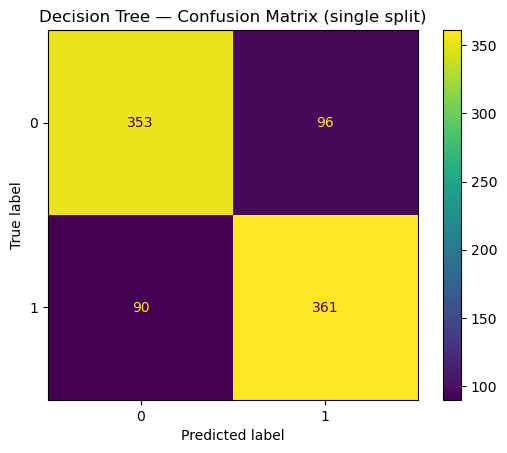

<Figure size 640x480 with 0 Axes>

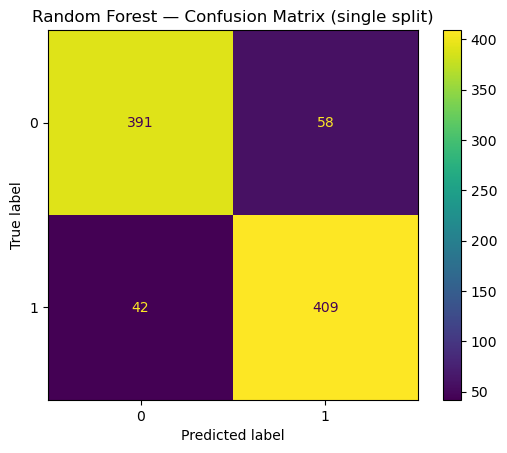

In [4]:
fig = plt.figure()
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree — Confusion Matrix (single split)")
plt.show()

fig = plt.figure()
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Random Forest — Confusion Matrix (single split)")
plt.show()

## 3. Repeated Trials (30 random splits)

To avoid lucky/unlucky splits, we repeat the experiment **30 times** with different random seeds, then compare distributions of accuracy.


In [5]:
n_runs = 30
acc_dt_runs = []
acc_rf_runs = []

for seed in range(n_runs):
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=seed
    )
    # Single tree
    dt = DecisionTreeClassifier(random_state=seed)
    dt.fit(Xtr, ytr)
    acc_dt_runs.append(accuracy_score(yte, dt.predict(Xte)))
    
    # Forest
    rf = RandomForestClassifier(
        n_estimators=400,
        max_features='sqrt',
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=seed
    )
    rf.fit(Xtr, ytr)
    acc_rf_runs.append(accuracy_score(yte, rf.predict(Xte)))

acc_dt_runs = np.array(acc_dt_runs)
acc_rf_runs = np.array(acc_rf_runs)

summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'Mean Accuracy': [acc_dt_runs.mean(), acc_rf_runs.mean()],
    'Std Accuracy': [acc_dt_runs.std(ddof=1), acc_rf_runs.std(ddof=1)],
    'Min': [acc_dt_runs.min(), acc_rf_runs.min()],
    'Max': [acc_dt_runs.max(), acc_rf_runs.max()]
})
summary

,Model,Mean Accuracy,Std Accuracy,Min,Max
0,Decision Tree,0.799704,0.012699,0.775556,0.832222
1,Random Forest,0.879296,0.008594,0.867778,0.895556


C:\Users\jung.suh\AppData\Local\Temp\ipykernel_12564\3446118079.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([acc_dt_runs, acc_rf_runs], labels=['Decision Tree', 'Random Forest'])


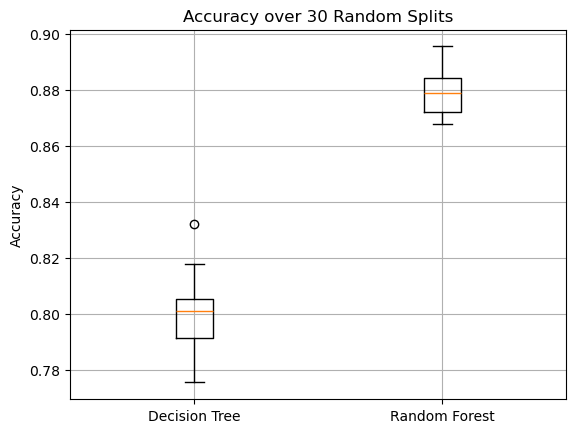

In [6]:
fig = plt.figure()
plt.boxplot([acc_dt_runs, acc_rf_runs], labels=['Decision Tree', 'Random Forest'])
plt.title("Accuracy over 30 Random Splits")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## 4. Why the Forest Wins Here

- The dataset has **correlated features** and **label noise**. A single tree tends to **overfit** idiosyncrasies of the training split.  
- The random forest averages many **diverse** trees (via bootstrap samples and random feature subspaces), reducing **variance** and improving **generalization**.
- Repeating across many splits makes the improvement **robust**, not a one-off result.


## 5. Feature Importances (Optional)

Random forests can provide useful (though imperfect) **feature importance** estimates.


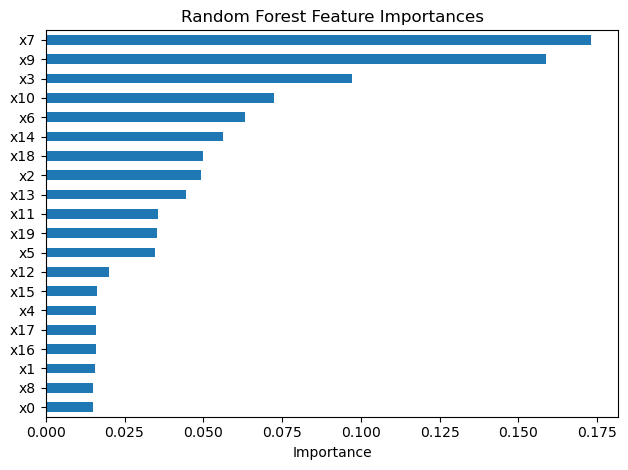

In [7]:
rf_full = RandomForestClassifier(
    n_estimators=600, max_features='sqrt', min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
).fit(X, y)

importances = pd.Series(rf_full.feature_importances_, index=[f'x{i}' for i in range(X.shape[1])]).sort_values()
fig = plt.figure()
importances.plot(kind='barh')
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()